# **Transformer Model**

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD DATASET
# =========================================================
print("Loading dataset...")
data = np.load("connect4_dedup_574k.npz")

X = data["X"].astype(np.float32)   # (N, 6, 7, 2)
y = data["y"].astype(np.int32)     # (N,)

print(f"Total samples: {X.shape[0]}")
# Distribution of target moves (Columns 0-6). 
# Center moves (Col 3) are often more frequent in optimal play.
print(f"Move distribution: {np.bincount(y)}")

# =========================================================
# 2. TRAIN / VAL / TEST SPLIT (STRICT OOS)
# =========================================================
# 75% Train, 12.5% Val, 12.5% Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test (OOS): {X_test.shape}")

# =========================================================
# 3. CUSTOM TRANSFORMER UTILITIES
# =========================================================
# Tells the model WHERE on the 6x7 grid each token came from.
class PositionalIndex(layers.Layer):
    def call(self, x):
        bs = tf.shape(x)[0]
        n = tf.shape(x)[1]
        idx = tf.range(n)
        return tf.tile(idx[None, :], [bs, 1])
    
# Creates dummy token that will eventually hold the global 
# representation of the board state for the final classification.
class ClassTokenIndex(layers.Layer):
    def call(self, x):
        bs = tf.shape(x)[0]
        return tf.zeros((bs, 1), dtype=tf.int32)

# =========================================================
# 4. BUILD TRANSFORMER MODEL
# =========================================================
def build_transformer(config):

    inp = layers.Input(shape=(6, 7, 2))

    # Flatten board → 42 tokens
    x = layers.Reshape((42, 2))(inp)

    # Mapping raw piece info to a higher-dim space (64)
    x = layers.Dense(config["embed_dim"], use_bias=False)(x)

    # Combining the embedding with its position on the board.
    pos = PositionalIndex()(x)
    pos_emb = layers.Embedding(42, config["embed_dim"])(pos)
    x = layers.Add()([x, pos_emb])

    # Class token: Inserting a learnable token at the start of the sequence.
    cls_idx = ClassTokenIndex()(x)
    cls_emb = layers.Embedding(1, config["embed_dim"])(cls_idx)
    x = layers.Concatenate(axis=1)([cls_emb, x])  # (B, 43, D)

    # Transformer blocks
    for _ in range(config["num_layers"]):
        # Attention allows the model to look at multiple areas 
        # of the board simultaneously
        ln1 = layers.LayerNormalization()(x)
        attn = layers.MultiHeadAttention(
            num_heads=config["num_heads"],
            key_dim=config["embed_dim"] // config["num_heads"]
        )(ln1, ln1)
        x = layers.Add()([x, attn])

        # FEED-FORWARD NETWORK (FFN) processes the information extracted by attention.
        ln2 = layers.LayerNormalization()(x)
        ffn = layers.Dense(config["ff_dim"], activation="gelu")(ln2)
        ffn = layers.Dropout(config["dropout"])(ffn)
        ffn = layers.Dense(config["embed_dim"])(ffn)
        ffn = layers.Dropout(config["dropout"])(ffn)
        x = layers.Add()([x, ffn])

    # Classification head (class token): Extract only the 'Class Token' (index 0) 
    # and map it to the 7 possible column moves.
    cls = x[:, 0, :]
    cls = layers.LayerNormalization()(cls)
    out = layers.Dense(7, activation="softmax")(cls)

    model = keras.Model(inp, out)
    model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=3e-4),
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
    )
    return model

# =========================================================
# 5. CONFIG + MODEL
# =========================================================
# Optimized parameters: 4 layers and 4 heads provide a balance 
# between depth and training speed.
CONFIG = {
    "embed_dim": 64,
    "num_heads": 4,
    "ff_dim": 128,
    "num_layers": 4,
    "dropout": 0.2
}

model = build_transformer(CONFIG)
model.summary()

# =========================================================
# 6. TRAINING
# =========================================================
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4
    ),
    keras.callbacks.ModelCheckpoint(
        "best_transformer.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

print("\nTraining Transformer...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)



Loading dataset...
Total samples: 574202
Move distribution: [ 60255  82144  98251 106431  93745  77101  56275]

Dataset split:
Train: (430651, 6, 7, 2)
Validation: (71775, 6, 7, 2)
Test (OOS): (71776, 6, 7, 2)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 6, 7, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 42, 2)     │          0 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 42, 64)    │        128 │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_index_7  │ (None, 42)        │          0 │ dense_70[0][0]    │
│ (PositionalIndex)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 42, 64)    │      2,688 │ positional_index… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_63 (Add)        │ (None, 42, 64)    │          0 │ dense_70[0][0],   │
│                     │                   │            │ embedding_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_token_index_7 │ (None, 1)         │          0 │ add_63[0][0]      │
│ (ClassTokenIndex)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 1, 64)     │         64 │ class_token_inde… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 43, 64)    │          0 │ embedding_15[0][… │
│ (Concatenate)       │                   │            │ add_63[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 43, 64)    │        128 │ concatenate_7[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 43, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_64 (Add)        │ (None, 43, 64)    │          0 │ concatenate_7[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 43, 64)    │        128 │ add_64[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_71 (Dense)    │ (None, 43, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_97          │ (None, 43, 128)   │          0 │ dense_71[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_72 (Dense)    │ (None, 43, 64)    │      8,256 │ dropout_97[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_98          │ (None, 43, 64)    │          0 │ dense_72[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_65 (Add)        │ (None, 43, 64)    │          0 │ add_64[0][0],     │
│                     │                   │            │ dropout_98[0][0]

 Total params: 137,351 (536.53 KB)

 Trainable params: 137,351 (536.53 KB)

 Non-trainable params: 0 (0.00 B)


Training Transformer...
Epoch 1/50
842/842 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.2128 - loss: 1.9261 - val_accuracy: 0.2845 - val_loss: 1.7381 - learning_rate: 3.0000e-04
Epoch 2/50
842/842 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2890 - loss: 1.7420 - val_accuracy: 0.2938 - val_loss: 1.7334 - learning_rate: 3.0000e-04
Epoch 3/50
842/842 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2958 - loss: 1.7253 - val_accuracy: 0.3009 - val_loss: 1.7129 - learning_rate: 3.0000e-04
Epoch 4/50
842/842 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2999 - loss: 1.7155 - val_accuracy: 0.3040 - val_loss: 1.7075 - learning_rate: 3.0000e-04
Epoch 5/50
842/842 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3087 - loss: 1.7053 - val_accuracy: 0.3083 - val_loss: 1.6989 - learning_rate: 3.0000e-04
Epoch 6/50
842/842 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3190 - loss: 1.6919 - val_accuracy: 0.3361 - val_loss: 1.6696 - learning_rate: 3.0000e-04
Epoch 7/50
842/842 ━━━━━━━━━━━━━━━━━━


OUT-OF-SAMPLE EVALUATION
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5434 - loss: 1.2297
OOS Loss: 1.2322
OOS Accuracy: 0.5427

Generating confusion matrix...
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


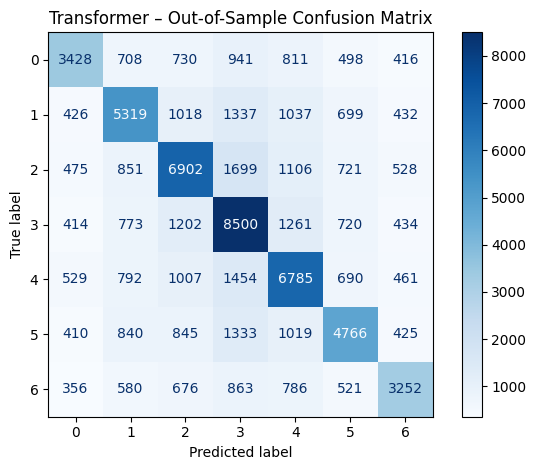


Sanity Check:
Train ≈ Val ≈ Test → Good generalization
Test << Val → Overfitting
Test >> Val → Data leakage / split issue


In [14]:
# =========================================================
# 7. OUT-OF-SAMPLE EVALUATION
# =========================================================
print("\n" + "=" * 60)
print("OUT-OF-SAMPLE EVALUATION")
print("=" * 60)

#best_model = keras.models.load_model("best_transformer.keras")

best_model = keras.models.load_model(
    "best_transformer.keras",
    custom_objects={
        "PositionalIndex": PositionalIndex,
        "ClassTokenIndex": ClassTokenIndex
    }
)


test_loss, test_acc = best_model.evaluate(
    X_test,
    y_test,
    batch_size=512,
    verbose=1
)


print(f"OOS Loss: {test_loss:.4f}")
print(f"OOS Accuracy: {test_acc:.4f}")

# =========================================================
# 8. CONFUSION MATRIX (OOS)
# =========================================================
print("\nGenerating confusion matrix...")

y_pred = np.argmax(best_model.predict(X_test, batch_size=512), axis=1)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Transformer – Out-of-Sample Confusion Matrix")
plt.tight_layout()
plt.show()

# =========================================================
# 9. SANITY CHECK MESSAGE
# =========================================================
print("\nSanity Check:")
print("Train ≈ Val ≈ Test → Good generalization")
print("Test << Val → Overfitting")
print("Test >> Val → Data leakage / split issue")


## Model Training & Architecture

### Training Data
The model was trained on a large dataset of Connect-4 positions generated through **Monte Carlo Tree Search (MCTS)** self-play. Instead of random gameplay, MCTS was used to produce expert-level move recommendations for each position.  

Key dataset characteristics:
- ~574,000 unique board positions after filtering
- 6×7×2 two-channel board representation
- Horizontal flip augmentation applied to training data
- Stratified train/validation/test split

Each position was encoded from the **current player’s perspective**, ensuring the model always reasons as “me vs. opponent,” regardless of which side generated the data.

---

### Input Representation
The board is represented as a **6×7×2 tensor**:
- Channel 0: current player’s pieces
- Channel 1: opponent’s pieces
- Empty cells are zero in both channels

This separation allows the model to learn patterns for each player independently.

---

### Model Architectures

#### 1. CNN (ResNet-20)
The primary model is a **ResNet-20 convolutional neural network** designed for spatial pattern recognition.

**Architecture highlights:**
- Input: 6×7×2 board tensor
- Initial 3×3 convolution (32 filters)
- 3 residual stacks:
  - Stack 1: 32 filters
  - Stack 2: 64 filters
  - Stack 3: 128 filters
- Skip connections to prevent vanishing gradients
- Average pooling + dropout
- Final dense layer with softmax over 7 columns

**Training configuration:**
- Optimizer: Adam (lr = 0.001, gradient clipping)
- Loss: Sparse categorical cross-entropy
- Batch size: 128
- Early stopping and learning-rate reduction on plateau

**Final performance:**
- Test accuracy: **~70%**
- Random baseline: ~14%

---

#### 2. Transformer Encoder
A secondary approach used a **Transformer architecture** adapted from NLP.

**Specifications:**
- 4 encoder layers
- 4 attention heads per layer
- Embedding dimension: 64
- Feed-forward dimension: 128
- ~137K parameters

The board is flattened into a sequence of 42 tokens, and positional embeddings allow the model to understand spatial relationships.

**Final performance:**
- Test accuracy: **~54.34%**

---

### Output Representation
Both models use a **7-class softmax output**, where each class corresponds to a column on the board.

- Output: probability distribution over legal moves
- Final move: column with highest probability (after masking full columns)

## Insights & Analysis

### CNN vs Transformer Performance
The CNN significantly outperformed the Transformer:
- CNN: ~70% test accuracy
- Transformer: ~54.34% test accuracy

This gap highlights the importance of **inductive bias**. Convolutional networks naturally capture local spatial relationships, which are critical in Connect-4 (e.g., three-in-a-row, diagonal threats). The Transformer, lacking this spatial prior, had to learn these relationships purely from data and struggled with the available dataset size.

---

### Key Model Strengths
**CNN:**
- Strong at immediate tactical patterns
- Effective defensive play
- Good at creating forks and short winning sequences
- Reliable central-column strategy

**Transformer:**
- Flexible global attention across the board
- Stronger understanding of overall board structure in some cases

---

### Key Weaknesses
**CNN:**
- Struggles with diagonal threat recognition
- Limited deep look-ahead
- Often plays defensively instead of pursuing winning strategies

**Transformer:**
- Over-biased toward center columns
- Poor performance on edge-column decisions
- Requires much larger datasets to compete with CNNs

---

### Behavioral Observations
Across gameplay tests:
- The model performs best in diverse, tactical positions.
- It struggles when opponents stack pieces vertically or follow structured patterns.
- The CNN tends to “play not to lose” rather than actively seek complex wins.

---

### Core Limitation: Supervised Learning Ceiling
Both models were trained to **imitate MCTS decisions**. This means:
- They cannot exceed the strength of the MCTS used to generate data.
- Strategic creativity is limited by the training signal.

---

### Future Improvements
1. Reinforcement learning through self-play
2. Hybrid neural network + search systems
3. Curriculum learning from simple to complex positions
4. Temporal or sequence-based modeling of move history

---

### Takeaway
The project demonstrates that neural networks trained on MCTS data can achieve **intermediate-level Connect-4 play** through pattern recognition alone.  
However, reaching expert-level performance likely requires reinforcement learning and deeper search integration.